In [ ]:
import sys
sys.path.append("..")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from src.data_loader import load_and_prepare
from src.models import MODEL_REGISTRY, train_model, evaluate_model
from src.tuning import tune_model, PARAM_GRIDS

c:\Users\Twinkle\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
X_train, X_test, y_train, y_test, scaler = load_and_prepare(
    path="../data/processed/kidney_features.csv",
    strategy="smote",
)
print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test :", X_test.shape, y_test.value_counts().to_dict())

Train: (400, 26) {1: 200, 0: 200}
Test : (80, 26) {1: 50, 0: 30}


In [ ]:
raw = pd.read_csv("../data/processed/kidney_clean.csv")
raw["classification"] = raw["classification"].astype(str).str.strip().str.lower().map(
    {"ckd": 1, "notckd": 0}
)

target_corr = raw.drop(columns=["id"]).corr(numeric_only=True)["classification"].drop("classification")
target_corr = target_corr.sort_values(key=abs, ascending=False)
print(target_corr)

hemo   -0.726368
pcv    -0.673129
sg     -0.659504
rc     -0.566163
al      0.531562
bgr     0.379321
bu      0.369393
sod    -0.334900
su      0.294555
bp      0.293693
sc      0.291245
age     0.227842
wc      0.177571
pot     0.065218
Name: classification, dtype: float64


In [ ]:
TOP_CORRELATED_FEATURE = target_corr.index[0]
TOP_CORRELATED_VALUE = target_corr.iloc[0]
print(f"Most correlated feature: {TOP_CORRELATED_FEATURE} ({TOP_CORRELATED_VALUE:.3f})")

Most correlated feature: hemo (-0.726)


In [ ]:
baseline_rows = []
for name in MODEL_REGISTRY:
    model = train_model(name, X_train, y_train)
    scores = evaluate_model(model, X_test, y_test)
    baseline_rows.append({"model": name, "stage": "untuned", **scores})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.drop(columns="confusion_matrix")

c:\Users\Twinkle\miniconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,stage,accuracy,precision,recall,f1,roc_auc
0,logreg,untuned,1.0000,1.000000,1.00,1.000000,1.000000
1,decision_tree,untuned,0.9625,1.000000,0.94,0.969072,0.970000
2,random_forest,untuned,1.0000,1.000000,1.00,1.000000,1.000000
3,knn,untuned,0.9125,1.000000,0.86,0.924731,0.981000
4,svm,untuned,0.9250,0.958333,0.92,0.938776,0.989333
5,xgboost,untuned,0.9875,1.000000,0.98,0.989899,0.999333
6,lightgbm,untuned,0.9875,1.000000,0.98,0.989899,1.000000


In [ ]:
candidates = ["random_forest", "xgboost", "lightgbm"]  # adjust to your Day 6 leaders

tuned_models = {}
tuned_rows = []

for name in candidates:
    search = tune_model(name, X_train, y_train, scoring="recall", n_iter=20)
    best_model = search.best_estimator_
    scores = evaluate_model(best_model, X_test, y_test)

    tuned_models[name] = best_model
    tuned_rows.append({
        "model": name,
        "stage": "tuned",
        "best_params": search.best_params_,
        **scores,
    })
    print(f"{name} best params: {search.best_params_}")

tuned_df = pd.DataFrame(tuned_rows)
tuned_df.drop(columns=["confusion_matrix", "best_params"])

random_forest best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}
xgboost best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
lightgbm best params: {'num_leaves': 63, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}


,model,stage,accuracy,precision,recall,f1,roc_auc
0,random_forest,tuned,0.9875,0.980392,1.00,0.990099,1.0
1,xgboost,tuned,1.0000,1.000000,1.00,1.000000,1.0
2,lightgbm,tuned,0.9875,1.000000,0.98,0.989899,1.0


In [ ]:
compare_df = pd.concat([
    baseline_df[baseline_df["model"].isin(candidates)],
    tuned_df.drop(columns="best_params"),
]).sort_values(["model", "stage"]).reset_index(drop=True)

compare_df.drop(columns="confusion_matrix")

,model,stage,accuracy,precision,recall,f1,roc_auc
0,lightgbm,tuned,0.9875,1.000000,0.98,0.989899,1.000000
1,lightgbm,untuned,0.9875,1.000000,0.98,0.989899,1.000000
2,random_forest,tuned,0.9875,0.980392,1.00,0.990099,1.000000
3,random_forest,untuned,1.0000,1.000000,1.00,1.000000,1.000000
4,xgboost,tuned,1.0000,1.000000,1.00,1.000000,1.000000
5,xgboost,untuned,0.9875,1.000000,0.98,0.989899,0.999333


In [ ]:
FINAL_MODEL_NAME = "xgboost"  # <- set this based on Cell 6's actual numbers
final_model = tuned_models[FINAL_MODEL_NAME]
final_scores = evaluate_model(final_model, X_test, y_test)
final_scores

{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'roc_auc': 1.0,
 'confusion_matrix': [[30, 0], [0, 50]]}

In [ ]:
justification = f"""
Final model: {FINAL_MODEL_NAME}
Recall: {final_scores['recall']:.3f} | Precision: {final_scores['precision']:.3f}
F1: {final_scores['f1']:.3f} | ROC-AUC: {final_scores['roc_auc']:.3f}
Confusion matrix: {final_scores['confusion_matrix']}

Rationale: chosen for highest recall among tuned candidates without a
precision collapse, consistent with a recall-first objective (a missed
CKD case is costlier than a false alarm).
"""
print(justification)


Final model: xgboost
Recall: 1.000 | Precision: 1.000
F1: 1.000 | ROC-AUC: 1.000
Confusion matrix: [[30, 0], [0, 50]]

Rationale: chosen for highest recall among tuned candidates without a
precision collapse, consistent with a recall-first objective (a missed
CKD case is costlier than a false alarm).



In [ ]:
import joblib

compare_df.to_csv("../data/processed/tuned_vs_untuned_comparison.csv", index=False)
joblib.dump(final_model, "../src/final_model.joblib")
print("Saved comparison table and final model.")

Saved comparison table and final model.


In [ ]:
# TreeExplainer works for random_forest / xgboost / lightgbm / decision_tree.
# For logreg or svm use shap.LinearExplainer / shap.KernelExplainer instead.
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

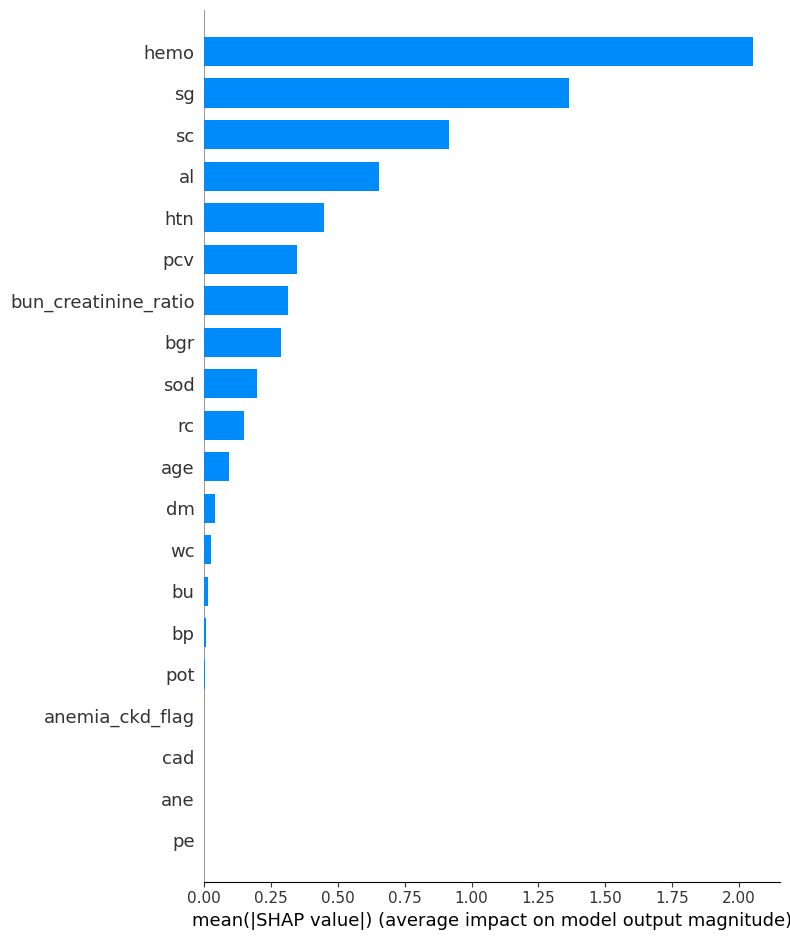

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

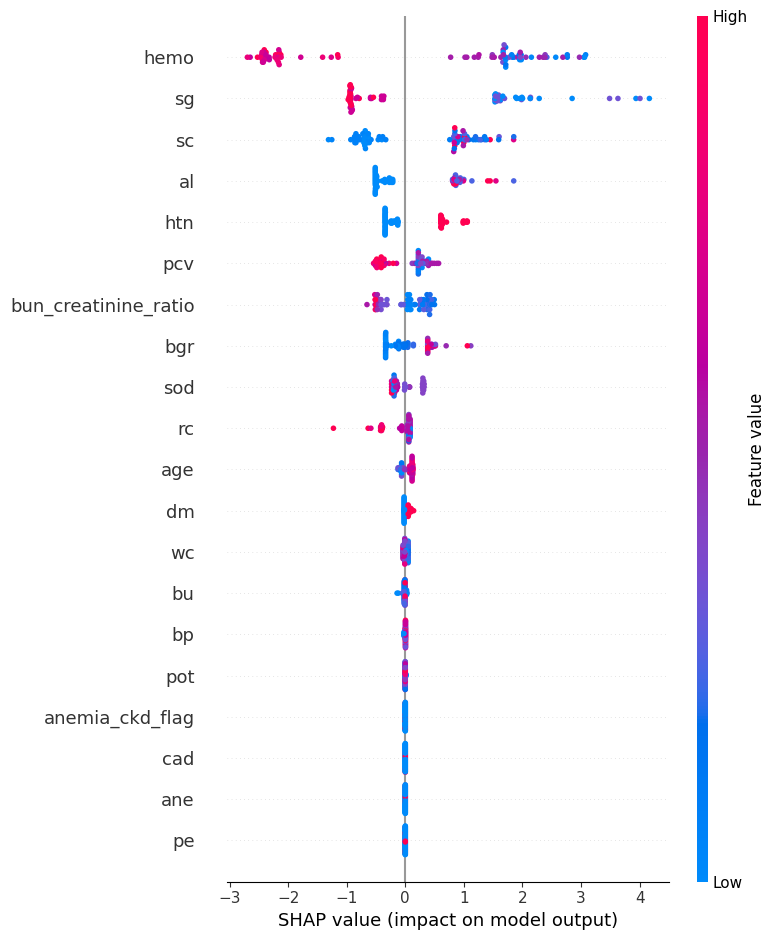

In [ ]:
shap.summary_plot(shap_values, X_test)

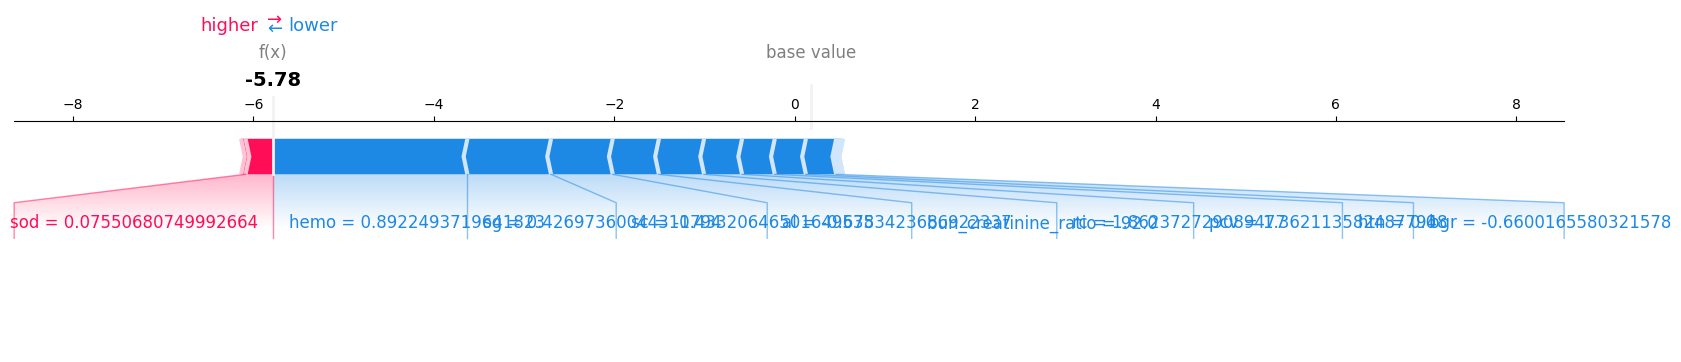

In [ ]:
i = 0  # pick any test-set row index
shap.force_plot(
    explainer.expected_value, shap_values[i], X_test.iloc[i], matplotlib=True
)

In [ ]:
pred = final_model.predict(X_test.iloc[[i]])[0]
proba = final_model.predict_proba(X_test.iloc[[i]])[0][1]
print(f"Patient {i} — predicted: {'CKD' if pred==1 else 'Not CKD'} (p={proba:.2f})")

Patient 0 — predicted: Not CKD (p=0.00)


In [ ]:
model_card = f"""
# Model Card — CKD Prediction

**Purpose:** Binary classification (CKD / not CKD) as clinical decision support.
Not a diagnostic tool.

**Final model:** {FINAL_MODEL_NAME}
**Training data:** {X_train.shape[0]} rows (post-SMOTE) from a {len(y_test)+len(y_train)}-row
source dataset, {X_train.shape[1]} features.

**Metrics (held-out test set, n={len(y_test)}):**
- Accuracy: {final_scores['accuracy']:.3f}
- Precision: {final_scores['precision']:.3f}
- Recall: {final_scores['recall']:.3f}
- F1: {final_scores['f1']:.3f}
- ROC-AUC: {final_scores['roc_auc']:.3f}
- Confusion matrix: {final_scores['confusion_matrix']}

**Why this model:** {justification.strip()}

**Top global drivers (SHAP):** fill in from Cell 10/11 — e.g. hemoglobin, serum
creatinine, albumin, specific gravity.

**Known limitations:**
- Small dataset (~400 records), single-source — may not generalize across
  populations, labs, or measurement equipment.
- Training set balanced via SMOTE synthetic samples, not additional real patients.
- Not validated prospectively or against a clinician-labeled holdout.

**Not for:** autonomous diagnosis, use without clinician review, populations
not represented in the training data.
"""
with open("../MODEL_CARD.md", "w") as f:
    f.write(model_card)
print(model_card)


# Model Card — CKD Prediction

**Purpose:** Binary classification (CKD / not CKD) as clinical decision support.
Not a diagnostic tool.

**Final model:** xgboost
**Training data:** 400 rows (post-SMOTE) from a 480-row
source dataset, 26 features.

**Metrics (held-out test set, n=80):**
- Accuracy: 1.000
- Precision: 1.000
- Recall: 1.000
- F1: 1.000
- ROC-AUC: 1.000
- Confusion matrix: [[30, 0], [0, 50]]

**Why this model:** Final model: xgboost
Recall: 1.000 | Precision: 1.000
F1: 1.000 | ROC-AUC: 1.000
Confusion matrix: [[30, 0], [0, 50]]

Rationale: chosen for highest recall among tuned candidates without a
precision collapse, consistent with a recall-first objective (a missed
CKD case is costlier than a false alarm).

**Top global drivers (SHAP):** fill in from Cell 10/11 — e.g. hemoglobin, serum
creatinine, albumin, specific gravity.

**Known limitations:**
- Small dataset (~400 records), single-source — may not generalize across
  populations, labs, or measurement equipment.
- Tr

In [ ]:
from src.evaluation import select_final_model

_, refactored_scores, _ = select_final_model("xgboost", tuned_models, X_test, y_test)
print("Notebook final_scores:", final_scores)
print("Module final_scores:  ", refactored_scores)
assert refactored_scores == final_scores, "src/evaluation.py output diverged from notebook!"
print("src/evaluation.py matches notebook results — refactor validated.")

Notebook final_scores: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0, 'confusion_matrix': [[30, 0], [0, 50]]}
Module final_scores:   {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0, 'confusion_matrix': [[30, 0], [0, 50]]}
src/evaluation.py matches notebook results — refactor validated.
